In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlalchemy
%matplotlib inline
%load_ext sql

In [2]:
m=pd.read_csv('extreme.csv').drop(columns=['Unnamed: 0','min']).sort_values(by=['max']).reset_index().drop(columns=['index']).reset_index().rename(columns={'index':'rank'})
m['rank']=m['rank']+1
m=m[['water year','max','rank']]
m

,water year,max,rank
0,1977,134,1
1,1976,271,2
2,1961,405,3
3,1933,783,4
4,1994,868,5
...,...,...,...
110,1965,28500,111
111,1956,31700,112
112,1986,34400,113
113,2017,36400,114


In [3]:
m['q_i']=(m['rank']-0.44)/(115+1-2*0.44)
m['p_i']=1-m['q_i']
m['T_estimated']=1/(m['p_i'])
m

,water year,max,rank,q_i,p_i,T_estimated
0,1977,134,1,0.004864,0.995136,1.004888
1,1976,271,2,0.013551,0.986449,1.013737
2,1961,405,3,0.022238,0.977762,1.022743
3,1933,783,4,0.030924,0.969076,1.031911
4,1994,868,5,0.039611,0.960389,1.041245
...,...,...,...,...,...,...
110,1965,28500,111,0.960389,0.039611,25.245614
111,1956,31700,112,0.969076,0.030924,32.337079
112,1986,34400,113,0.977762,0.022238,44.968750
113,2017,36400,114,0.986449,0.013551,73.794872


In [4]:
xhat=np.mean(m['max'])
sd=np.std(m['max'])
alpha=np.sqrt(6)*sd/np.pi
u=xhat-0.5772*alpha
xhat,sd,alpha,u

(9097.365217391305, 9094.44323541955, 7090.908299657867, 5004.492946828784)

,water year,max,rank,q_i,p_i,T_estimated,(x-u)/α),p_theoretical,T_theoretical
17,1908,2020,18,0.152536,0.847464,1.179992,-0.420890,0.217988,1.278752
105,1909,20800,106,0.916956,0.083044,12.041841,2.227572,0.897816,9.786292
63,1910,7200,64,0.552120,0.447880,2.232739,0.309623,0.480118,1.923513
106,1911,22400,107,0.925643,0.074357,13.448598,2.453213,0.917579,12.132805
10,1912,1100,11,0.091730,0.908270,1.100995,-0.550634,0.176515,1.214351
...,...,...,...,...,...,...,...,...,...
84,2018,11800,85,0.734538,0.265462,3.767016,0.958341,0.681453,3.139250
73,2019,8980,74,0.638985,0.361015,2.769971,0.560648,0.565051,2.299122
42,2020,4150,43,0.369701,0.630299,1.586549,-0.120505,0.323658,1.478543
15,2021,1670,16,0.135163,0.864837,1.156288,-0.470249,0.201817,1.252846


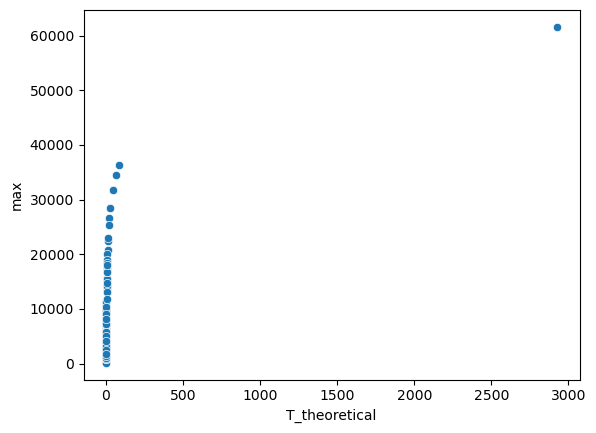

In [5]:
m['(x-u)/α)']=(m['max']-u)/alpha
m['p_theoretical']=np.exp(-np.exp(-m['(x-u)/α)']))
m['T_theoretical']=1/(1-m['p_theoretical'])
m=m.sort_values(by=['water year'])
display(m)
sns.scatterplot(x=m["T_theoretical"], y=m["max"]);

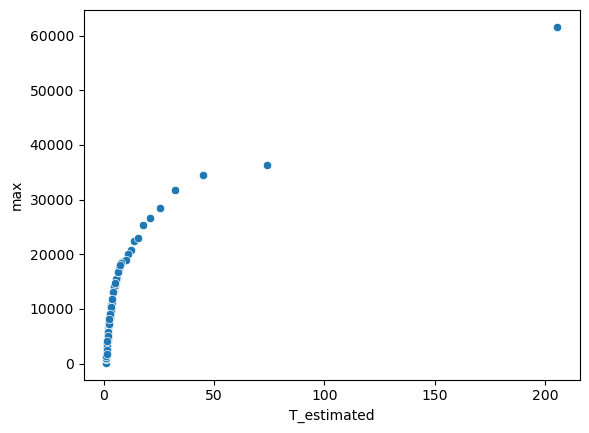

In [6]:
sns.scatterplot(x=m["T_estimated"], y=m["max"]);

### log10 transformation for return period
https://serc.carleton.edu/hydromodules/steps/166250.html

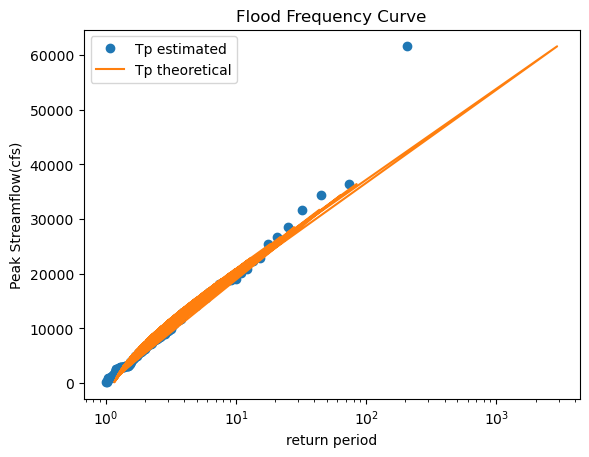

In [32]:
plt.semilogx(m["T_estimated"], m["max"],'o',label="Tp estimated")
plt.semilogx(m["T_theoretical"], m["max"],'-',label="Tp theoretical");
leg = plt.legend(loc='upper left')
plt.title('Flood Frequency Curve')
plt.xlabel('return period')
plt.ylabel('Peak Streamflow(cfs)');

### checking values for three different climate zones of CA
https://climatedataguide.ucar.edu/climate-data/palmer-drought-severity-index-pdsi

In [8]:
ca=pd.read_csv('climate zone.csv')
ca=ca.drop(columns=['Column14']).rename(columns={'Column1':'year','Column2':'Jan','Column3':'Feb','Column4':'Mar','Column5':'Apr','Column6':'May','Column7':'Jun','Column8':'Jul','Column9':'Aug','Column10':'Sep','Column11':'Oct','Column12':'Nov','Column13':'Dec'})
#seperate three diff regions:402,403,405
ca1=ca[((ca['year']>=402051896) & (ca['year']<=402052022)) ]
ca1['year']=ca1['year']-402050000
ca1=ca1.replace(-99.99, 0)
display(ca1)
ca2=ca[((ca['year']>=403051896) & (ca['year']<=403052022)) ]
ca2['year']=ca2['year']-403050000
ca2=ca2.replace(-99.99, 0)
display(ca2)
ca3=ca[((ca['year']>=405051896) & (ca['year']<=405052022)) ]
ca3['year']=ca3['year']-405050000
ca3=ca3.replace(-99.99, 0)
display(ca3)
ca = pd.concat([ca1,ca2,ca3])
display(ca)
#how to convert to water year

/tmp/ipykernel_24/705869381.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca1['year']=ca1['year']-402050000


,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
3201,1896,2.38,1.12,1.29,3.28,4.21,3.74,3.59,3.46,3.43,2.75,3.46,2.88
3202,1897,1.98,2.51,2.93,-0.44,-0.91,-0.73,-0.84,-0.90,-0.90,-0.53,-0.59,-0.96
3203,1898,-1.88,-1.61,-2.43,-2.85,0.63,1.11,1.40,1.28,1.16,-0.23,-0.54,-1.13
3204,1899,-0.82,-1.64,1.39,0.74,1.00,1.17,1.24,1.46,1.00,2.85,2.84,-0.07
3205,1900,-0.43,-1.04,-1.12,0.23,0.33,0.40,0.32,0.27,0.21,1.35,1.37,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,2018,-2.42,-3.16,-1.91,-1.17,-1.12,-1.30,-1.66,-1.95,-2.24,-2.47,-2.16,-2.30
3324,2019,0.49,2.33,2.73,2.28,3.47,3.11,2.83,2.57,2.80,-0.67,-1.34,-0.72
3325,2020,-1.25,-2.30,-2.26,-2.42,-1.71,-1.54,-1.59,-1.68,-2.08,-2.82,-2.98,-3.15
3326,2021,-3.30,-3.56,-3.71,-4.12,-4.56,-5.28,-5.89,-5.89,-5.40,-2.74,-3.34,-2.54


/tmp/ipykernel_24/705869381.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca2['year']=ca2['year']-403050000


,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
3329,1896,1.94,0.91,1.70,3.45,4.16,3.46,3.45,3.74,3.83,3.26,3.87,3.42
3330,1897,2.85,3.95,4.60,-0.55,-0.96,-0.92,-1.07,-1.14,-1.22,-0.34,-0.20,-0.11
3331,1898,-0.70,-0.70,-0.99,-1.48,0.30,0.60,0.59,-0.08,-0.07,-0.14,-0.20,-0.95
3332,1899,-0.75,-1.38,1.10,0.61,1.02,0.87,1.10,1.66,1.15,2.97,3.18,3.31
3333,1900,2.61,1.84,1.56,1.88,1.61,1.32,1.03,0.71,0.78,1.82,2.39,1.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,2018,-1.88,-2.59,1.08,1.47,1.77,-0.27,-0.30,-0.72,-1.20,-1.37,-1.39,-1.75
3452,2019,0.28,2.10,2.21,1.84,2.38,2.02,1.96,1.56,1.88,-0.49,-1.22,-1.01
3453,2020,-1.59,-2.60,-2.56,-2.51,-2.47,-2.52,-2.67,-2.75,-3.10,-3.67,-3.76,-3.87
3454,2021,-3.72,-3.91,-3.89,-4.19,-4.34,-4.73,-4.97,-5.11,-4.83,-2.35,-2.71,-1.29


/tmp/ipykernel_24/705869381.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca3['year']=ca3['year']-405050000


,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
3585,1896,2.01,0.85,1.28,2.40,2.63,2.94,3.04,3.23,2.93,3.11,3.15,2.46
3586,1897,2.14,3.02,3.53,-0.70,-1.05,-1.32,-1.43,-1.36,-1.43,0.81,-0.46,-0.74
3587,1898,-1.49,-2.08,-2.50,-3.03,-2.44,-2.60,-2.65,-2.49,-1.77,-1.84,-2.15,-2.76
3588,1899,-2.42,-3.25,1.04,0.54,0.74,1.25,1.33,1.28,0.80,2.31,2.38,-0.02
3589,1900,-0.47,-1.30,-1.70,0.49,1.62,2.22,2.24,1.96,1.71,1.82,3.25,2.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3707,2018,-2.78,-3.76,-2.37,-2.19,-2.13,-2.04,-2.14,-2.32,-2.50,-2.63,-2.07,-2.48
3708,2019,0.08,1.40,1.73,0.94,2.47,2.87,2.83,-0.10,-0.30,-0.87,-1.12,-0.82
3709,2020,-1.74,-2.84,-2.60,-2.04,-1.81,-1.70,-1.80,-1.89,-2.15,-2.77,-3.08,-3.55
3710,2021,-3.44,-4.12,-4.36,-4.87,-5.64,-6.48,-6.86,-6.62,-6.38,-4.16,-4.48,-2.79


,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
3201,1896,2.38,1.12,1.29,3.28,4.21,3.74,3.59,3.46,3.43,2.75,3.46,2.88
3202,1897,1.98,2.51,2.93,-0.44,-0.91,-0.73,-0.84,-0.90,-0.90,-0.53,-0.59,-0.96
3203,1898,-1.88,-1.61,-2.43,-2.85,0.63,1.11,1.40,1.28,1.16,-0.23,-0.54,-1.13
3204,1899,-0.82,-1.64,1.39,0.74,1.00,1.17,1.24,1.46,1.00,2.85,2.84,-0.07
3205,1900,-0.43,-1.04,-1.12,0.23,0.33,0.40,0.32,0.27,0.21,1.35,1.37,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3707,2018,-2.78,-3.76,-2.37,-2.19,-2.13,-2.04,-2.14,-2.32,-2.50,-2.63,-2.07,-2.48
3708,2019,0.08,1.40,1.73,0.94,2.47,2.87,2.83,-0.10,-0.30,-0.87,-1.12,-0.82
3709,2020,-1.74,-2.84,-2.60,-2.04,-1.81,-1.70,-1.80,-1.89,-2.15,-2.77,-3.08,-3.55
3710,2021,-3.44,-4.12,-4.36,-4.87,-5.64,-6.48,-6.86,-6.62,-6.38,-4.16,-4.48,-2.79


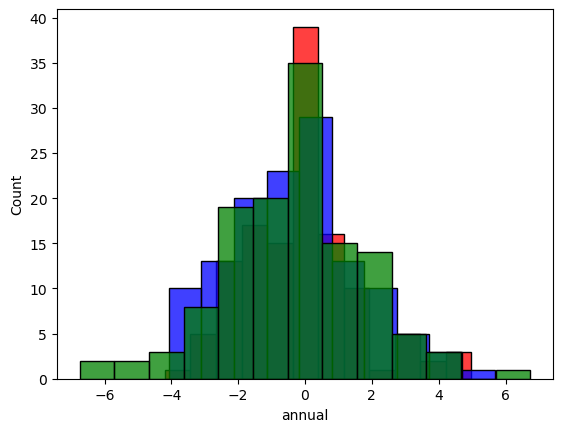

In [9]:
ca1['annual']=(ca1['Jan']+ca1['Feb']+ca1['Mar']+ca1['Apr']+ca1['May']+ca1['Jun']+ca1['Jul']+ca1['Aug']+ca1['Sep']+ca1['Oct']+ca1['Nov']+ca1['Dec'])/12
ca2['annual']=(ca2['Jan']+ca2['Feb']+ca2['Mar']+ca2['Apr']+ca2['May']+ca2['Jun']+ca2['Jul']+ca2['Aug']+ca2['Sep']+ca2['Oct']+ca2['Nov']+ca2['Dec'])/12
ca3['annual']=(ca3['Jan']+ca3['Feb']+ca3['Mar']+ca3['Apr']+ca3['May']+ca3['Jun']+ca3['Jul']+ca3['Aug']+ca3['Sep']+ca3['Oct']+ca3['Nov']+ca3['Dec'])/12
sns.histplot(data=ca1,x='annual',color='red')
sns.histplot(data=ca2,x='annual',color='blue')
sns.histplot(data=ca3,x='annual',color='green');

### time series by years

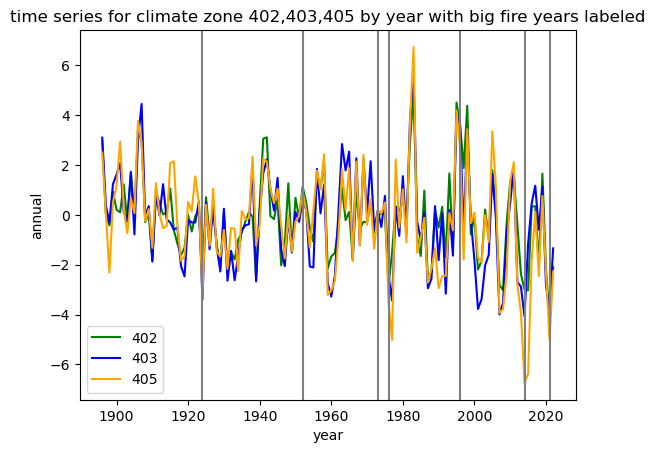

In [10]:
sns.lineplot(data=ca1, x="year",y='annual',color='green',label='402')
sns.lineplot(data=ca2, x="year",y='annual',color='blue',label='403')
sns.lineplot(data=ca3, x="year",y='annual',color='orange',label='405')
plt.axvline(x=1924, color='grey')
plt.axvline(x=1952, color='grey')
plt.axvline(x=1973, color='grey')
plt.axvline(x=1976, color='grey')
plt.axvline(x=1996, color='grey')
plt.axvline(x=2014, color='grey')
plt.axvline(x=2021, color='grey')
plt.title('time series for climate zone 402,403,405 by year with big fire years labeled');

In [11]:
anualave=pd.Series((ca1['annual'].array+ca2['annual'].array+ca3['annual'].array)/3).to_frame()
#cave=ca1.copy()
anualave['year']=np.arange(1896,2023)
anualave=anualave.rename(columns={0:'annual'})

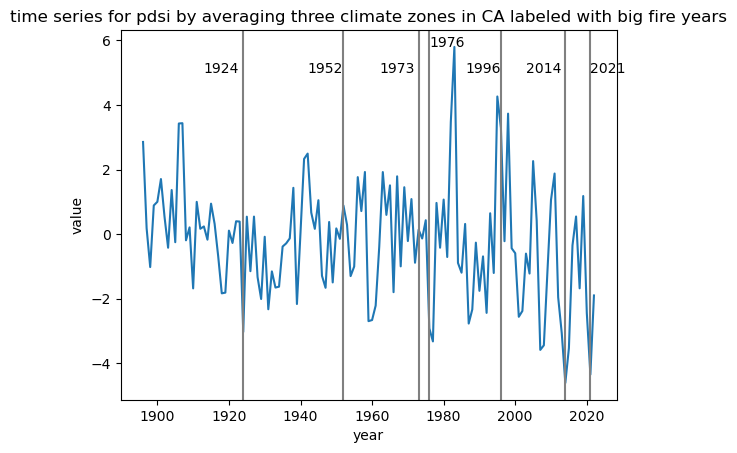

In [33]:
sns.lineplot(data=anualave,x="year",y='annual')
plt.axvline(x=1924, color='grey')
plt.axvline(x=1952, color='grey')
plt.axvline(x=1973, color='grey')
plt.axvline(x=1976, color='grey')
plt.axvline(x=1996, color='grey')
plt.axvline(x=2014, color='grey')
plt.axvline(x=2021, color='grey')
plt.annotate('1924', xy=(1924, 5), xytext=(1913, 5))
plt.annotate('1952', xy=(1952, 5), xytext=(1942, 5))
plt.annotate('1973', xy=(1973, 5), xytext=(1962, 5))
plt.annotate('1976', xy=(1976, 5), xytext=(1976, 5.8))
plt.annotate('1996', xy=(1996, 5), xytext=(1986, 5))
plt.annotate('2014', xy=(2014, 5), xytext=(2003, 5))
plt.annotate('2021', xy=(2021, 5), xytext=(2021, 5))
plt.title('time series for pdsi by averaging three climate zones in CA labeled with big fire years')
plt.ylabel('value');

anualave=anualave[['year','annual']]
anualave2=anualave[anualave['year']>=1908]
anualave2['drought']=np.ones(115).astype(str)
anualave2["drought"] = 'no'
for row in anualave2.itertuples():
    if anualave2.at[row.Index, "annual"] <=-2:
        anualave2.at[row.Index, "drought"] = 'yes'
anualave2
anualave2.to_csv('pdsi.csv')  

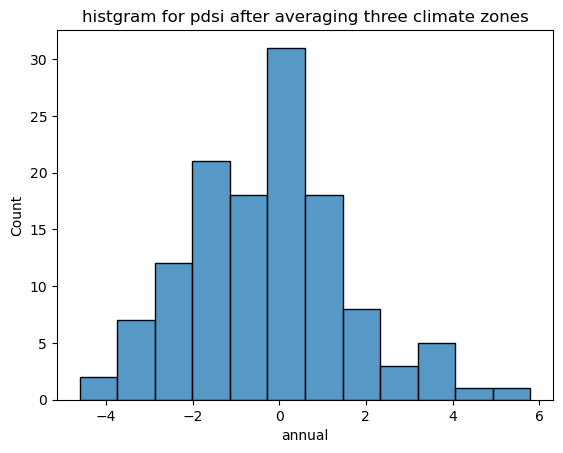

In [13]:
sns.histplot(data=anualave,x='annual')
plt.title('histgram for pdsi after averaging three climate zones');

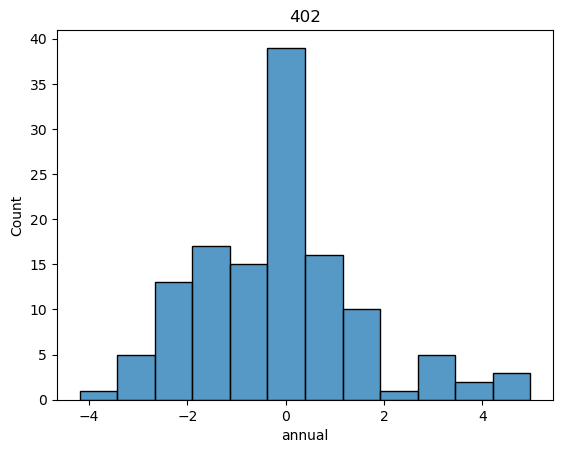

In [14]:
sns.histplot(data=ca1,x='annual')
plt.title("402");

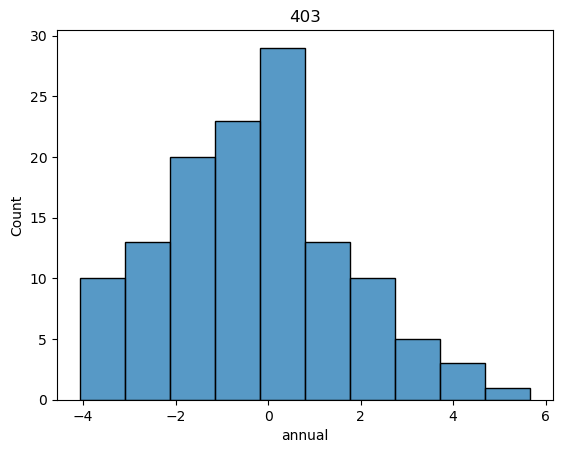

In [15]:
sns.histplot(data=ca2,x='annual')
plt.title("403");

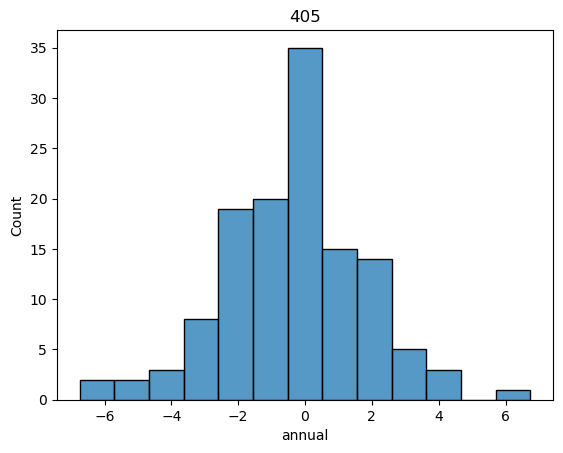

In [16]:
sns.histplot(data=ca3,x='annual')
plt.title("405");

In [17]:
ca1m=ca1.drop(columns=['annual'])
ca1mm=pd.melt(ca1m,id_vars=['year']).rename(columns={'variable':'month'})
#factor_dict= {'month':{'Jan':1 ,'Feb':2,'Mar':3,'Apr': 4,'May':5,'Jun': 6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}}
#ca1m.replace(factor_dict, inplace=True)
ca1mm['month'] = ca1mm['month'].replace(['Jan' ,'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],[1,2,3,4,5,6,7,8,9,10,11,12])
ca1mm=ca1mm.sort_values(by=['year','month']).reset_index(drop=True)
ca1mm=ca1mm.drop(ca1mm.index[1518:1524])
display(ca1mm)

ca2m=ca2.drop(columns=['annual'])
ca2mm=pd.melt(ca2m,id_vars=['year']).rename(columns={'variable':'month'})
ca2mm['month'] = ca2mm['month'].replace(['Jan' ,'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],[1,2,3,4,5,6,7,8,9,10,11,12])
ca2mm=ca2mm.sort_values(by=['year','month']).reset_index(drop=True)
ca2mm=ca2mm.drop(ca2mm.index[1518:1524])
display(ca2mm)

ca3m=ca3.drop(columns=['annual'])
ca3mm=pd.melt(ca3m,id_vars=['year']).rename(columns={'variable':'month'})
ca3mm['month'] = ca3mm['month'].replace(['Jan' ,'Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],[1,2,3,4,5,6,7,8,9,10,11,12])
ca3mm=ca3mm.sort_values(by=['year','month']).reset_index(drop=True)
ca3mm=ca3mm.drop(ca3mm.index[1518:1524])
display(ca3mm)

,year,month,value
0,1896,1,2.38
1,1896,2,1.12
2,1896,3,1.29
3,1896,4,3.28
4,1896,5,4.21
...,...,...,...
1513,2022,2,-4.33
1514,2022,3,-4.95
1515,2022,4,-4.25
1516,2022,5,-4.21


,year,month,value
0,1896,1,1.94
1,1896,2,0.91
2,1896,3,1.70
3,1896,4,3.45
4,1896,5,4.16
...,...,...,...
1513,2022,2,-2.74
1514,2022,3,-3.39
1515,2022,4,-2.72
1516,2022,5,-2.79


,year,month,value
0,1896,1,2.01
1,1896,2,0.85
2,1896,3,1.28
3,1896,4,2.40
4,1896,5,2.63
...,...,...,...
1513,2022,2,-4.30
1514,2022,3,-4.70
1515,2022,4,-4.63
1516,2022,5,-4.86


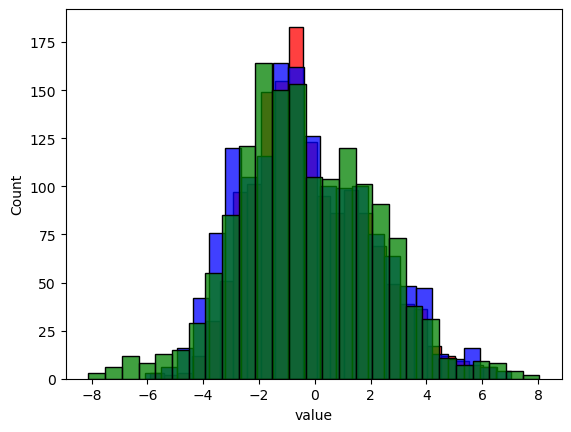

In [18]:
sns.histplot(data=ca1mm,x='value',color='red')
sns.histplot(data=ca2mm,x='value',color='blue')
sns.histplot(data=ca3mm,x='value',color='green');

precwr=precw.copy()
precwr['time']=precwr['water year']+precwr['water month']*0.1
precwr
plt.figure(figsize=(24,8))
sns.lineplot(precwr['time'], precwr['precipition']);

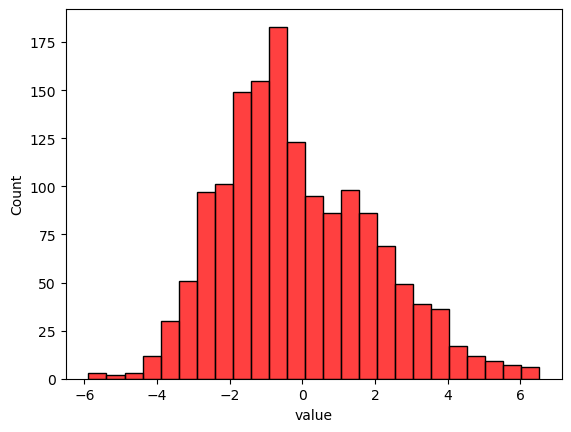

In [19]:
sns.histplot(data=ca1mm,x='value',color='red');

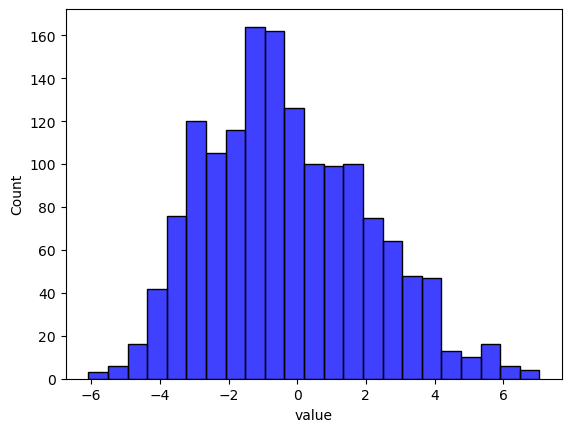

In [20]:
sns.histplot(data=ca2mm,x='value',color='blue');

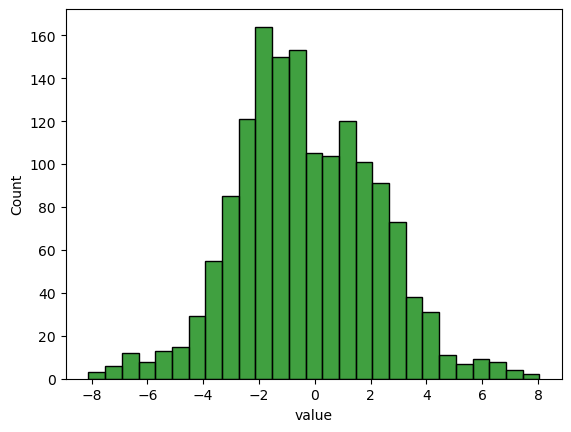

In [21]:
sns.histplot(data=ca3mm,x='value',color='green');

In [22]:
ca1mm

,year,month,value
0,1896,1,2.38
1,1896,2,1.12
2,1896,3,1.29
3,1896,4,3.28
4,1896,5,4.21
...,...,...,...
1513,2022,2,-4.33
1514,2022,3,-4.95
1515,2022,4,-4.25
1516,2022,5,-4.21


###analyze by water year

In [23]:
###get water month
ca1mm['month']=ca1mm['month'].astype(str)
ca1mmw=ca1mm.copy()
orginm3=ca1mm['month']
orginy3=ca1mm['year']
factor_dict= {'month':{'10':1 ,'11':2,'12':3,'1': 4,'2':5,'3': 6,'4':7,'5':8,'6':9,'7':10,'8':11,'9':12}}
ca1mmw.replace(factor_dict, inplace=True)
ca1mmw=ca1mmw.rename(columns={'month':'water month'})
ca1mmw['month']=orginm3.astype(int)

###get water year
for row in ca1mmw.itertuples():
    if ca1mmw.at[row.Index, "month"] >=10:
        ca1mmw.at[row.Index, "year"] = ca1mmw.at[row.Index, "year"]+1
ca1mmw=ca1mmw.rename(columns={'year':'water year'})
ca1mmw['year']=orginy3
ca1mmw=ca1mmw[['year','water year','month','water month','value']]
ca1mmw


,year,water year,month,water month,value
0,1896,1896,1,4,2.38
1,1896,1896,2,5,1.12
2,1896,1896,3,6,1.29
3,1896,1896,4,7,3.28
4,1896,1896,5,8,4.21
...,...,...,...,...,...
1513,2022,2022,2,5,-4.33
1514,2022,2022,3,6,-4.95
1515,2022,2022,4,7,-4.25
1516,2022,2022,5,8,-4.21


In [24]:
###get water month
ca2mm['month']=ca2mm['month'].astype(str)
ca2mmw=ca2mm.copy()
orginm4=ca2mm['month']
orginy4=ca2mm['year']
factor_dict= {'month':{'10':1 ,'11':2,'12':3,'1': 4,'2':5,'3': 6,'4':7,'5':8,'6':9,'7':10,'8':11,'9':12}}
ca2mmw.replace(factor_dict, inplace=True)
ca2mmw=ca2mmw.rename(columns={'month':'water month'})
ca2mmw['month']=orginm3.astype(int)

###get water year
for row in ca2mmw.itertuples():
    if ca2mmw.at[row.Index, "month"] >=10:
        ca2mmw.at[row.Index, "year"] = ca2mmw.at[row.Index, "year"]+1
ca2mmw=ca2mmw.rename(columns={'year':'water year'})
ca2mmw['year']=orginy4
ca2mmw=ca2mmw[['year','water year','month','water month','value']]
ca2mmw

,year,water year,month,water month,value
0,1896,1896,1,4,1.94
1,1896,1896,2,5,0.91
2,1896,1896,3,6,1.70
3,1896,1896,4,7,3.45
4,1896,1896,5,8,4.16
...,...,...,...,...,...
1513,2022,2022,2,5,-2.74
1514,2022,2022,3,6,-3.39
1515,2022,2022,4,7,-2.72
1516,2022,2022,5,8,-2.79


In [25]:
###get water month
ca3mm['month']=ca3mm['month'].astype(str)
ca3mmw=ca3mm.copy()
orginm5=ca3mm['month']
orginy5=ca3mm['year']
factor_dict= {'month':{'10':1 ,'11':2,'12':3,'1': 4,'2':5,'3': 6,'4':7,'5':8,'6':9,'7':10,'8':11,'9':12}}
ca3mmw.replace(factor_dict, inplace=True)
ca3mmw=ca3mmw.rename(columns={'month':'water month'})
ca3mmw['month']=orginm3.astype(int)

###get water year
for row in ca3mmw.itertuples():
    if ca3mmw.at[row.Index, "month"] >=10:
        ca3mmw.at[row.Index, "year"] = ca3mmw.at[row.Index, "year"]+1
ca3mmw=ca3mmw.rename(columns={'year':'water year'})
ca3mmw['year']=orginy5
ca3mmw=ca3mmw[['year','water year','month','water month','value']]
ca3mmw

,year,water year,month,water month,value
0,1896,1896,1,4,2.01
1,1896,1896,2,5,0.85
2,1896,1896,3,6,1.28
3,1896,1896,4,7,2.40
4,1896,1896,5,8,2.63
...,...,...,...,...,...
1513,2022,2022,2,5,-4.30
1514,2022,2022,3,6,-4.70
1515,2022,2022,4,7,-4.63
1516,2022,2022,5,8,-4.86


### time series by months

In [26]:
ca1mm

,year,month,value
0,1896,1,2.38
1,1896,2,1.12
2,1896,3,1.29
3,1896,4,3.28
4,1896,5,4.21
...,...,...,...
1513,2022,2,-4.33
1514,2022,3,-4.95
1515,2022,4,-4.25
1516,2022,5,-4.21


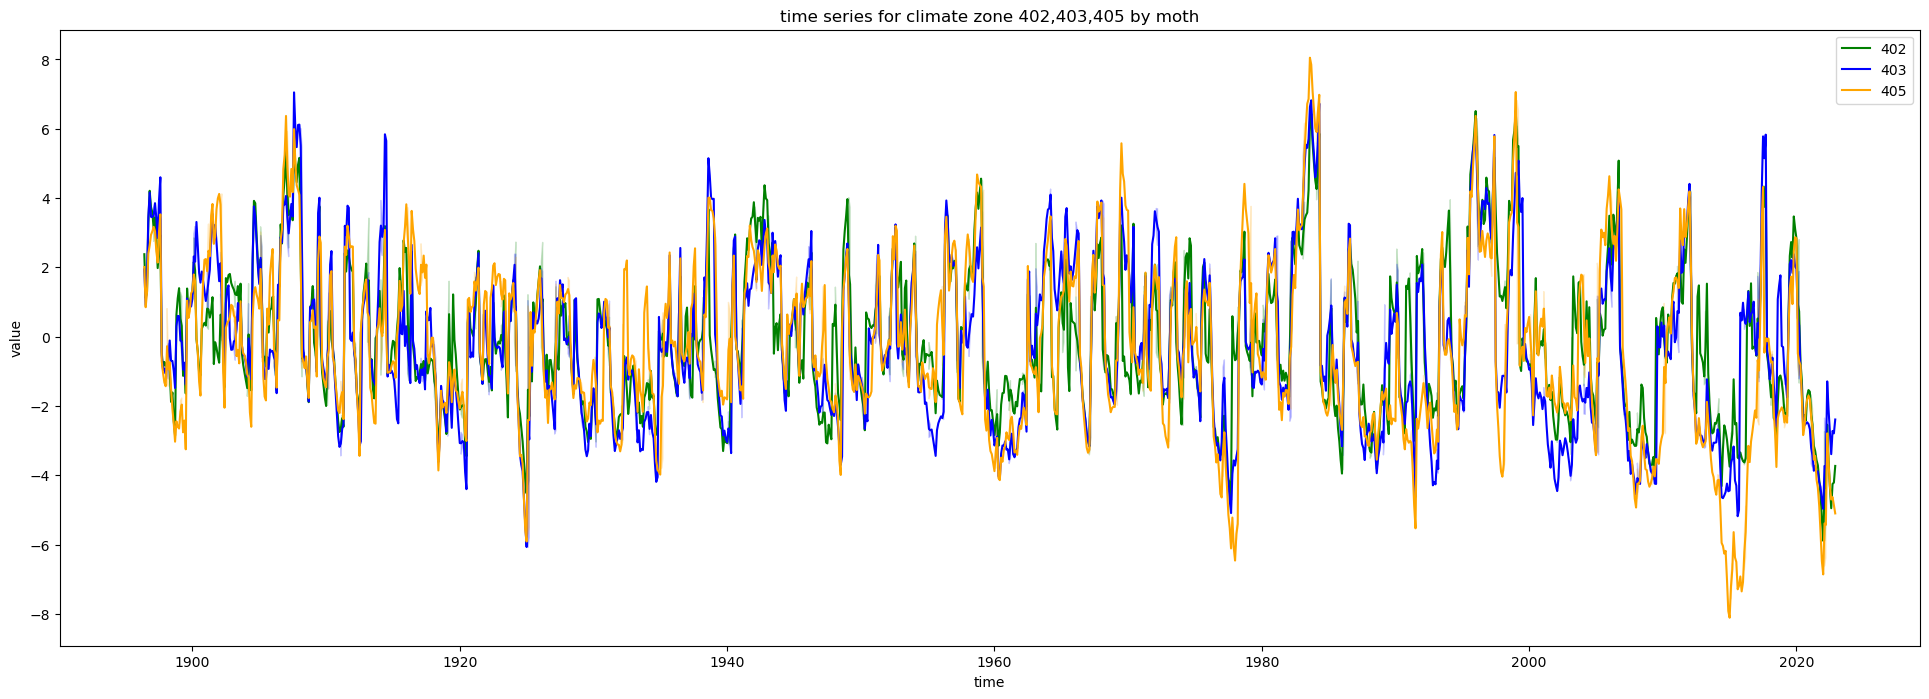

In [27]:
ca1mmwr=ca1mmw.copy()
ca1mmwr['time']=ca1mmwr['water year']+ca1mmwr['water month']*0.1

ca2mmwr=ca2mmw.copy()
ca2mmwr['time']=ca2mmwr['water year']+ca2mmwr['water month']*0.1

ca3mmwr=ca3mmw.copy()
ca3mmwr['time']=ca3mmwr['water year']+ca3mmwr['water month']*0.1
plt.figure(figsize=(24,8))
sns.lineplot(data=ca1mmwr, x="time",y='value',color='green',label='402')
sns.lineplot(data=ca2mmwr, x="time",y='value',color='blue',label='403')
sns.lineplot(data=ca3mmwr, x="time",y='value',color='orange',label='405')
plt.title('time series for climate zone 402,403,405 by moth');
#sns.lineplot(ca1mmwr['time'], ca1mmwr['value']);

In [28]:
cawm=ca1mmw.copy()
cawm['value']=(ca1mmw['value']+ca2mmw['value']+ca3mmw['value'])/3
cawm['val']=cawm['year']+cawm['month']/100
cawm=cawm[(cawm['val']>=1907.10) &(cawm['val']<=2021.09)]
cawm=cawm.drop(columns=['val'])
cawm.to_csv('pdsi.csv') 